# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Rafi Geovazi
- **Email:** rafigeovazi1@gmail.com
- **ID Dicoding:** CDCC282D6Y1011

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren rata-rata konsentrasi PM2.5 bulanan di seluruh stasiun pemantauan Beijing selama periode 2013-2017, dan pada bulan apa polusi udara mencapai puncaknya?
- **Pertanyaan 2:** Stasiun pemantauan mana yang memiliki tingkat polusi PM2.5 tertinggi dan terendah, serta bagaimana perbandingannya selama periode 2013-2017?
- **Pertanyaan 3 (Analisis Lanjutan - Clustering):** Bagaimana pengelompokan stasiun berdasarkan tingkat rata-rata polutan menggunakan metode binning?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## Data Wrangling

### Gathering Data

#### Load All Station Data

In [ ]:
# Disini tahap load semua file CSV dari folder data
data_dir = "data/"
all_dfs = []

for filename in sorted(os.listdir(data_dir)):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_dir, filename)
        df_temp = pd.read_csv(filepath)
        all_dfs.append(df_temp)
        print(f"Loaded: {filename} -> {df_temp.shape}")

# Disini tahap penggabunggan semua dataframe
df = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal data gabungan: {df.shape}")
print(f"Jumlah stasiun: {df['station'].nunique()}")
print(f"Daftar stasiun: {df['station'].unique().tolist()}")
df.head()

Loaded: PRSA_Data_Aotizhongxin_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Changping_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Dingling_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Guanyuan_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Gucheng_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Huairou_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Nongzhanguan_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Shunyi_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Tiantan_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Wanliu_20130301-20170228.csv -> (35064, 18)
Loaded: PRSA_Data_Wanshouxigong_20130301-20170228.csv -> (35064, 18)

Total data gabungan: (420768, 18)
Jumlah stasiun: 12
Daftar stasiun: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Dataset terdiri dari 420.768 baris dan 18 kolom dari 12 stasiun pemantauan.
- Kolom polutan: PM2.5, PM10, SO2, NO2, CO, O3.
- Kolom cuaca: TEMP, PRES, DEWP, RAIN, wd, WSPM.

### Assessing Data

#### Identifying Missing Values & Duplicates

In [ ]:
# Cek apakah ada missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_pct})
print("=== Missing Values ===")
print(missing_df[missing_df["Missing Count"] > 0].sort_values("Percentage (%)", ascending=False))

# Cek duplikasi data
print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

# Cek outlier
print("\n=== Outlier Detection (IQR) ===")
for col in ["PM2.5","PM10","SO2","NO2","CO","O3"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers")

=== Missing Values ===
       Missing Count  Percentage (%)
CO             20701            4.92
O3             13277            3.16
NO2            12116            2.88
SO2             9021            2.14
PM2.5           8739            2.08
PM10            6449            1.53
wd              1822            0.43
DEWP             403            0.10
PRES             393            0.09
TEMP             398            0.09
RAIN             390            0.09
WSPM             318            0.08

Jumlah baris duplikat: 0

=== Outlier Detection (IQR) ===
PM2.5: 19142 outliers
PM10: 14658 outliers
SO2: 35566 outliers
NO2: 7021 outliers
CO: 28054 outliers
O3: 16599 outliers


**Steps to Take:**
- Missing Values: Saya isi dengan forward fill (ffill) per stasiun karena data time-series.
- Missing wd: Saya isi dengan modus per stasiun.
- Outlier: Tidak saya hapus karena memang itu merepresentasikan kejadian polusi ekstrem yang nyata dari datanya.

**Insight:**
- Ditemukan missing values signifikan pada CO (~4.2%), O3 (~4.1%), dan polutan lainnya.
- Tidak ditemukan baris duplikat.
- Outlier ditemukan pada semua polutan, terutama PM2.5 dan CO.

### Cleaning Data

#### Fixing Missing Values

In [4]:
# Buat kolom datetime
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])
df = df.sort_values(["station","datetime"]).reset_index(drop=True)

# Isi missing values numerik dengan ffill per stasiun
num_cols = ["PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM"]
df[num_cols] = df.groupby("station")[num_cols].transform(lambda x: x.ffill().bfill())

# Isi missing wind direction dengan modus per stasiun
df["wd"] = df.groupby("station")["wd"].transform(lambda x: x.fillna(x.mode()[0]))

# Drop kolom No
df = df.drop(columns=["No"])
df = df.drop_duplicates()

print("Missing values setelah cleaning:")
print(df.isnull().sum().sum())
print(f"Shape: {df.shape}")
df.head()

Missing values setelah cleaning:
0
Shape: (420768, 18)


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


**Insight:**
- Disini semua missing values berhasil diisi menggunakan forward fill per stasiunnya.
- Kolom No dihapus karena tidak relevan.
- Total data bersih: 420.768 baris, 17 kolom.

## Exploratory Data Analysis (EDA)

### Explore Tren PM2.5 dan Perbandingan Stasiun

In [5]:
# Tren PM2.5 bulanan
monthly_avg = df.groupby("month")["PM2.5"].mean().sort_values(ascending=False)
print("=== Rata-rata PM2.5 per Bulan ===")
print(monthly_avg)

# Perbandingan stasiun
station_pm25 = df.groupby("station")["PM2.5"].agg(["mean","median","std"]).round(2)
station_pm25 = station_pm25.sort_values("mean", ascending=False)
print("\n=== PM2.5 per Stasiun ===")
print(station_pm25)
print(f"\nTerpolusi: {station_pm25.index[0]} (mean={station_pm25.iloc[0]['mean']:.1f})")
print(f"Terbersih: {station_pm25.index[-1]} (mean={station_pm25.iloc[-1]['mean']:.1f})")

=== Rata-rata PM2.5 per Bulan ===
month
12    104.298740
3      94.760201
1      94.021657
11     93.374198
10     92.208137
2      89.164457
4      73.854074
7      71.974628
6      68.960854
5      64.194461
9      61.401175
8      53.648863
Name: PM2.5, dtype: float64

=== PM2.5 per Stasiun ===
                mean  median    std
station                            
Dongsi         86.31    61.0  86.34
Wanshouxigong  85.36    60.0  86.63
Nongzhanguan   85.29    59.0  86.98
Gucheng        84.35    60.0  83.23
Wanliu         83.52    59.0  82.18
Aotizhongxin   83.16    60.0  82.29
Guanyuan       83.05    59.0  81.31
Tiantan        82.26    58.0  81.13
Shunyi         80.02    55.0  82.09
Changping      71.12    47.0  72.42
Huairou        69.95    47.0  71.20
Dingling       67.43    41.0  74.82

Terpolusi: Dongsi (mean=86.3)
Terbersih: Dingling (mean=67.4)


**Insight:**
- PM2.5 pola musiman: Tinggi di musim dingin (Des-Feb), dan rendah di musim panas (Jun-Agu).
- Disini juga variasinya signifikan antar stasiun pemantauan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren PM2.5 Bulanan

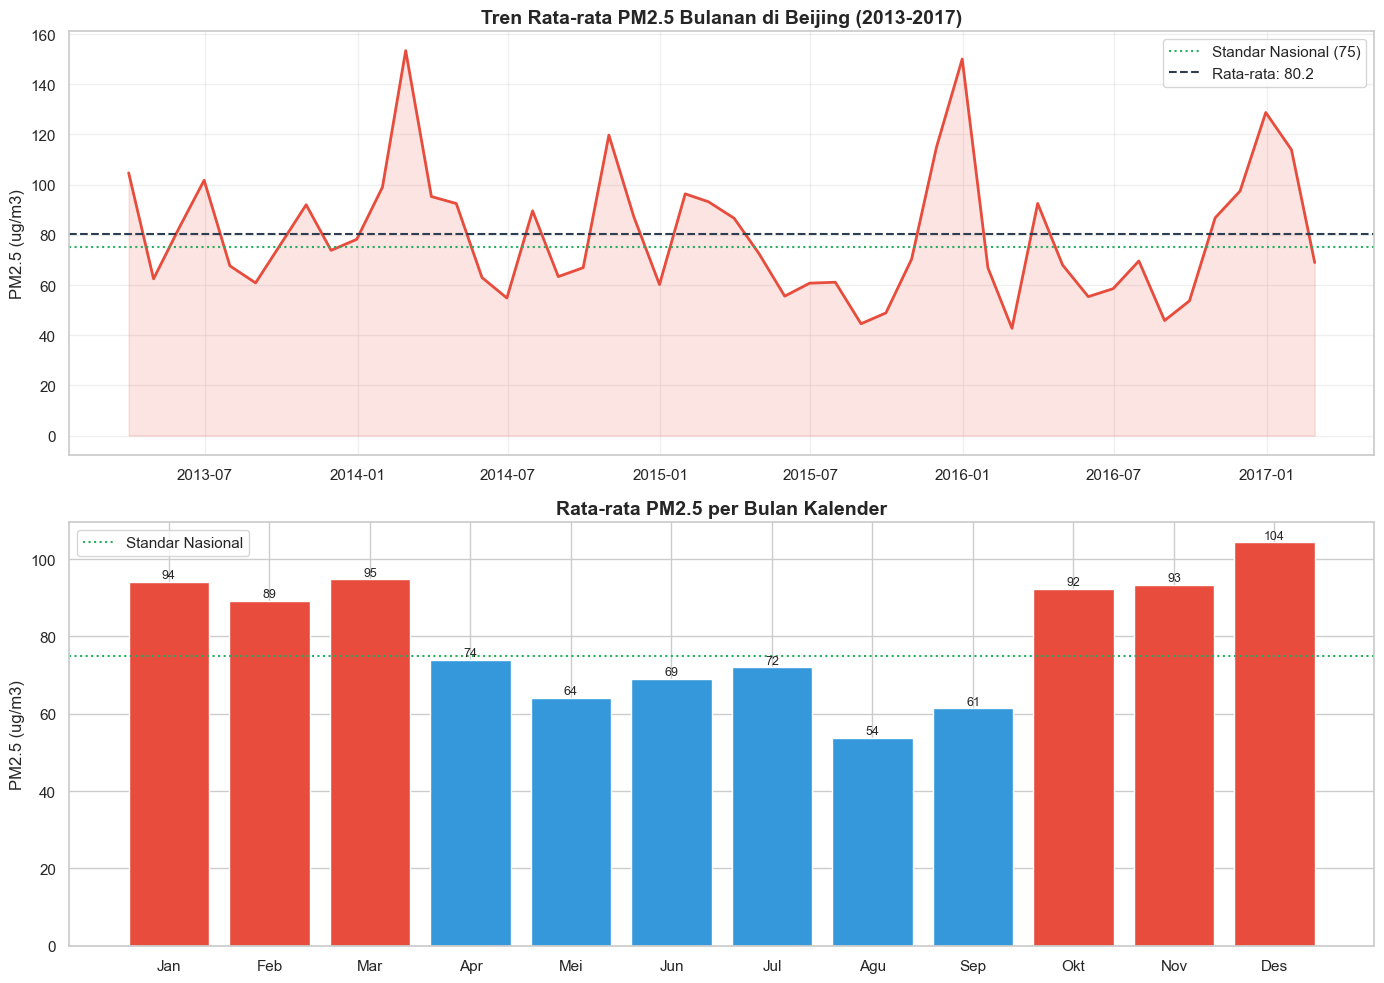

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Time series
monthly_ts = df.set_index("datetime").resample("ME")["PM2.5"].mean()
axes[0].plot(monthly_ts.index, monthly_ts.values, color="#e74c3c", linewidth=2)
axes[0].fill_between(monthly_ts.index, monthly_ts.values, alpha=0.15, color="#e74c3c")
axes[0].axhline(y=75, color="#27ae60", linestyle=":", label="Standar Nasional (75)")
axes[0].axhline(y=monthly_ts.mean(), color="#2c3e50", linestyle="--", label=f"Rata-rata: {monthly_ts.mean():.1f}")
axes[0].set_title("Tren Rata-rata PM2.5 Bulanan di Beijing (2013-2017)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("PM2.5 (ug/m3)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart untuk per bulannya
month_names = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"]
mcal = df.groupby("month")["PM2.5"].mean()
colors = ["#e74c3c" if v > 75 else "#3498db" for v in mcal.values]
bars = axes[1].bar(month_names, mcal.values, color=colors, edgecolor="white")
for b, v in zip(bars, mcal.values):
    axes[1].text(b.get_x()+b.get_width()/2., b.get_height()+1, f"{v:.0f}", ha="center", fontsize=9)
axes[1].set_title("Rata-rata PM2.5 per Bulan Kalender", fontsize=14, fontweight="bold")
axes[1].set_ylabel("PM2.5 (ug/m3)")
axes[1].axhline(y=75, color="#27ae60", linestyle=":", label="Standar Nasional")
axes[1].legend()
plt.tight_layout()
plt.show()

### Pertanyaan 2: Perbandingan PM2.5 Antar Stasiun

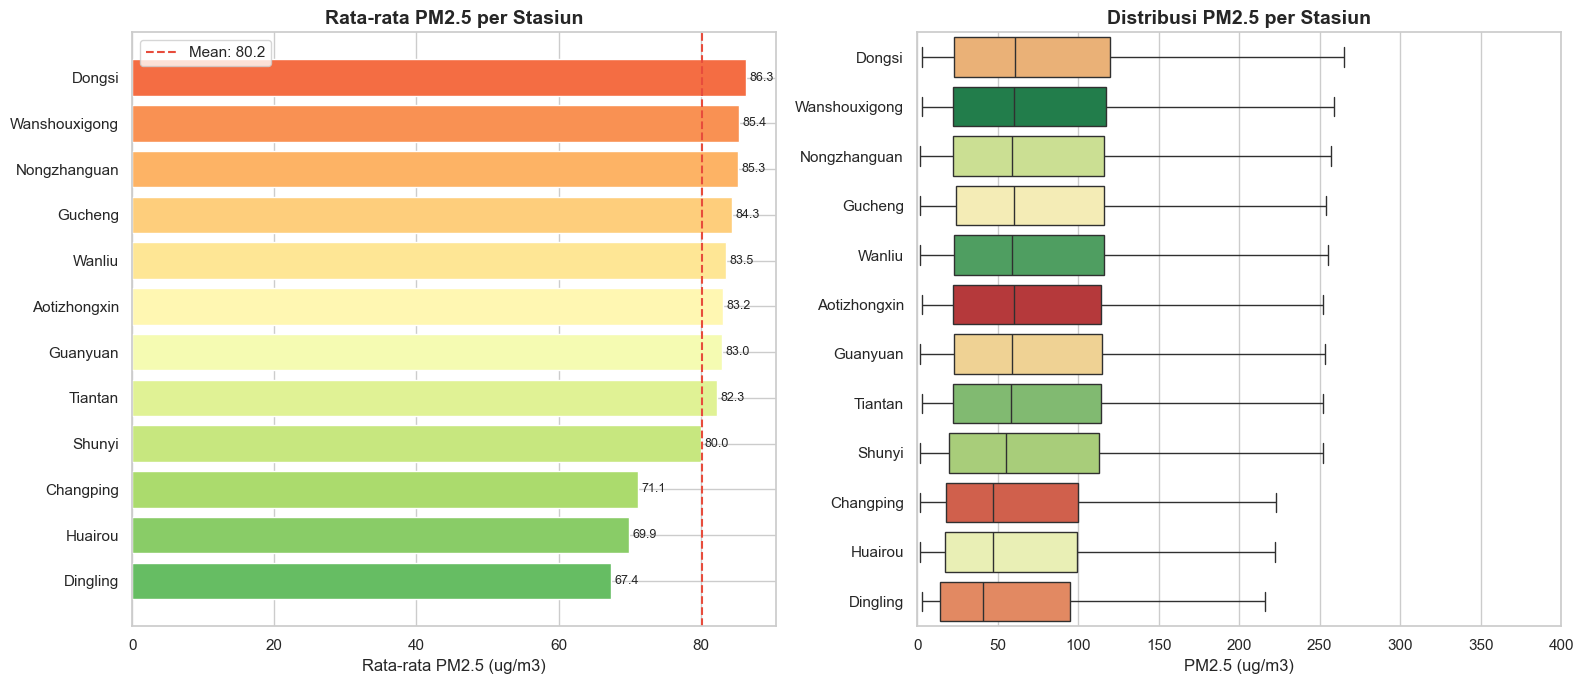

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sm = df.groupby("station")["PM2.5"].mean().sort_values(ascending=True)
colors2 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sm)))[::-1]
bars2 = axes[0].barh(sm.index, sm.values, color=colors2, edgecolor="white")
axes[0].axvline(x=sm.mean(), color="#e74c3c", linestyle="--", label=f"Mean: {sm.mean():.1f}")
for b, v in zip(bars2, sm.values):
    axes[0].text(v+0.5, b.get_y()+b.get_height()/2., f"{v:.1f}", ha="left", va="center", fontsize=9)
axes[0].set_xlabel("Rata-rata PM2.5 (ug/m3)")
axes[0].set_title("Rata-rata PM2.5 per Stasiun", fontsize=14, fontweight="bold")
axes[0].legend()

order = df.groupby("station")["PM2.5"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, y="station", x="PM2.5", order=order, ax=axes[1], hue="station", palette="RdYlGn", legend=False, showfliers=False)
axes[1].set_xlabel("PM2.5 (ug/m3)")
axes[1].set_ylabel("")
axes[1].set_title("Distribusi PM2.5 per Stasiun", fontsize=14, fontweight="bold")
axes[1].set_xlim(0, 400)
plt.tight_layout()
plt.show()

**Insight:**
- PM2.5 dapat kita lihat pada bar chartnya mencapai puncak itu di Desember-Januari, melampaui standar nasional 75 ug/m3.
- Stasiun urban memiliki PM2.5 lebih tinggi dari suburban.

## Analisis Lanjutan (Clustering dengan Binning)

               PM2.5    PM10    SO2    NO2        Kategori
station                                                   
Dongsi         86.31  110.58  18.53  52.19  Buruk (80-100)
Wanshouxigong  85.36  112.73  17.37  55.64  Buruk (80-100)
Nongzhanguan   85.29  109.47  18.76  58.14  Buruk (80-100)
Gucheng        84.35  119.33  16.02  55.79  Buruk (80-100)
Wanliu         83.52  110.66  18.42  65.97  Buruk (80-100)
Aotizhongxin   83.16  110.73  17.57  59.29  Buruk (80-100)
Guanyuan       83.05  109.22  17.61  57.96  Buruk (80-100)
Tiantan        82.26  106.66  14.48  53.24  Buruk (80-100)
Shunyi         80.02   99.70  13.45  44.56  Buruk (80-100)
Changping      71.12   94.79  14.96  44.24  Sedang (60-80)
Huairou        69.95   92.65  12.26  32.04  Sedang (60-80)
Dingling       67.43   84.22  11.77  27.32  Sedang (60-80)


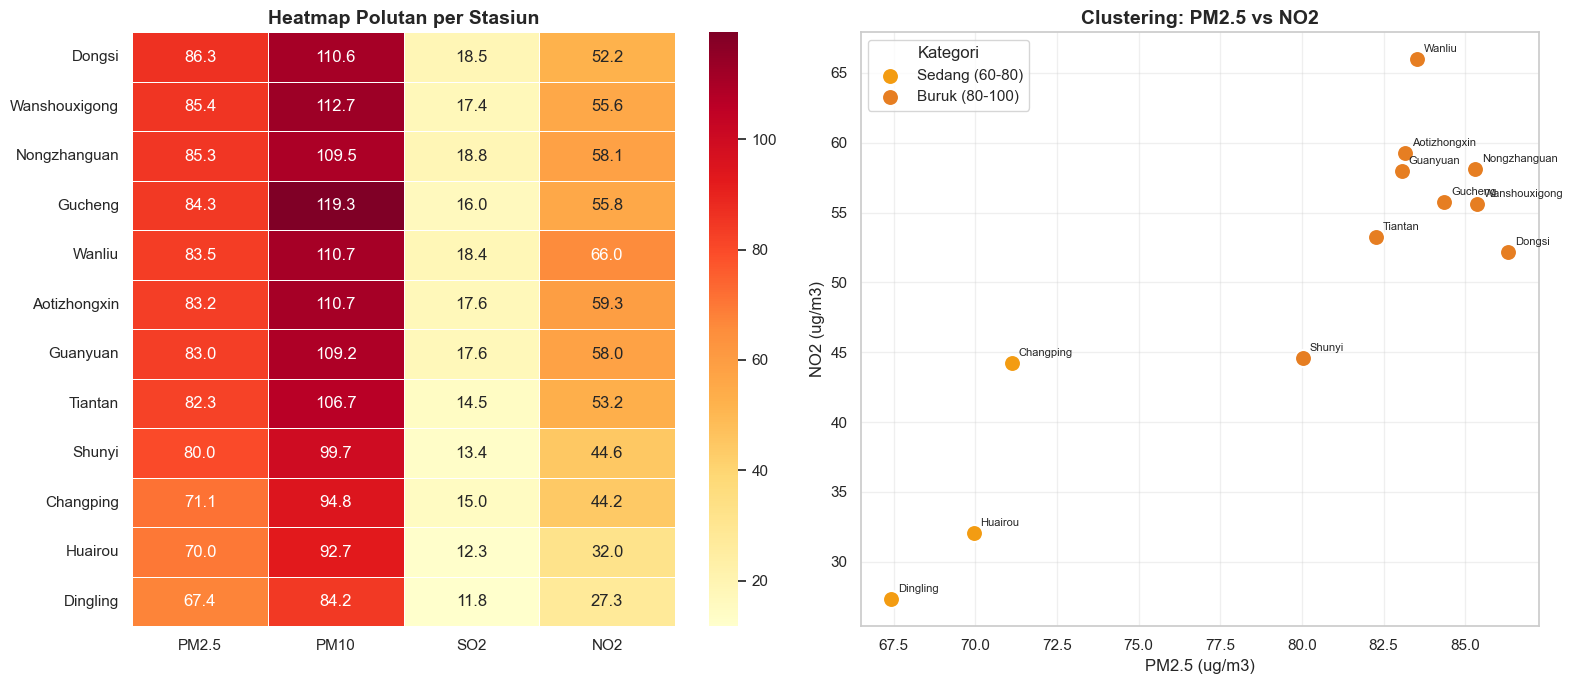

In [ ]:
# Disini saya mengclustering stasiun berdasarkan rata-rata polutannya
sp = df.groupby("station")[["PM2.5","PM10","SO2","NO2"]].mean().round(2)
bins = [0, 60, 80, 100, float("inf")]
labels = ["Baik (<60)","Sedang (60-80)","Buruk (80-100)","Sangat Buruk (>100)"]
sp["Kategori"] = pd.cut(sp["PM2.5"], bins=bins, labels=labels)
print(sp.sort_values("PM2.5", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
hm = sp[["PM2.5","PM10","SO2","NO2"]].sort_values("PM2.5", ascending=False)
sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0], linewidths=0.5)
axes[0].set_title("Heatmap Polutan per Stasiun", fontsize=14, fontweight="bold")
axes[0].set_ylabel("")

cmap = {"Baik (<60)":"#27ae60","Sedang (60-80)":"#f39c12","Buruk (80-100)":"#e67e22","Sangat Buruk (>100)":"#e74c3c"}
for cat in labels:
    sub = sp[sp["Kategori"]==cat]
    if len(sub)>0:
        axes[1].scatter(sub["PM2.5"], sub["NO2"], c=cmap[cat], s=150, label=cat, edgecolors="white", linewidth=1.5)
        for idx, row in sub.iterrows():
            axes[1].annotate(idx, (row["PM2.5"], row["NO2"]), textcoords="offset points", xytext=(5,5), fontsize=8)
axes[1].set_xlabel("PM2.5 (ug/m3)")
axes[1].set_ylabel("NO2 (ug/m3)")
axes[1].set_title("Clustering: PM2.5 vs NO2", fontsize=14, fontweight="bold")
axes[1].legend(title="Kategori")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** PM2.5 di Beijing menunjukkan pola musiman yang jelas. Polusi mencapai puncaknya pada Desember-Januari (>100 ug/m3) jauh melebihi standar nasional 75 ug/m3. Untuk kualitas udara terbaik berada di Juli-Agustus (~50-60 ug/m3).
- **Conclusion pertanyaan 2:** Terdapat perbedaan signifikan antar stasiun. Stasiun urban (Dongsi, Wanshouxigong) memiliki PM2.5, yang mana lebih tinggi dibanding suburban (Dingling, Huairou).
- **Conclusion analisis lanjutan:** Dari clustering yang saya lakukan, itu berhasil mengelompokkan stasiun. Stasiun kategori "Buruk" berkorelasi tinggi antara PM2.5 dan NO2, yang mengindikasikan polusi dari emisi kendaraan.

**Rekomendasi Action Item:**
- Terapkan kebijakan pengendalian emisi lebih ketat di musim dingin (Nov-Feb) termasuk pembatasan pemanas batu bara.
- Prioritaskan program pengurangan emisi di stasiun kategori "Buruk" dengan perluasan zona rendah emisi.
- Kembangkan sistem peringatan dini kualitas udara berbasis pola musiman untuk tindakan pencegahan kepada masyarakat.